# Analysis of data collected in a survey concerning flying etiquette

### Respondents answered 26 closed questions focusing on their attitude towards specific behaviors on board of a plane. 
The behaviors ranged from reclining one's seat to bringing babies on flight. 
The survey also collected demographic data, including age, household income, and parental status.

###### Data source: https://github.com/fivethirtyeight/data/blob/master/flying-etiquette-survey/flying-etiquette.csv

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/gos12/Data-Analytics-Portfolio/blob/main/Flying_etiquette.ipynb)

In [1]:
#importing libraries

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as tcr
import matplotlib.colors as cl
import matplotlib.cm   #color maps
import numpy as np   #descriptive stats
import seaborn as sns  #for removing spines in plots
from functools import reduce
%matplotlib inline

pd.options.mode.chained_assignment = None  #disable unnecessary warnings

## Data exploration

In [2]:
#reading in the data

url='https://raw.githubusercontent.com/fivethirtyeight/data/master/flying-etiquette-survey/flying-etiquette.csv'
etiq_raw=pd.read_csv(url)
etiq_raw.head()

,RespondentID,How often do you travel by plane?,Do you ever recline your seat when you fly?,How tall are you?,Do you have any children under 18?,"In a row of three seats, who should get to use the two arm rests?","In a row of two seats, who should get to use the middle arm rest?",Who should have control over the window shade?,Is itrude to move to an unsold seat on a plane?,"Generally speaking, is it rude to say more than a few words tothe stranger sitting next to you on a plane?",...,Is itrude to wake a passenger up if you are trying to walk around?,"In general, is itrude to bring a baby on a plane?","In general, is it rude to knowingly bring unruly children on a plane?",Have you ever used personal electronics during take off or landing in violation of a flight attendant's direction?,Have you ever smoked a cigarette in an airplane bathroom when it was against the rules?,Gender,Age,Household Income,Education,Location (Census Region)
0,3436139758,Once a year or less,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,3434278696,Once a year or less,About half the time,"6'3""",Yes,The arm rests should be shared,The arm rests should be shared,Everyone in the row should have some say,"No, not rude at all","No, not at all rude",...,"No, not at all rude","No, not at all rude","No, not at all rude",No,No,Male,30-44,NaN,Graduate degree,Pacific
2,3434275578,Once a year or less,Usually,"5'8""",No,Whoever puts their arm on the arm rest first,The arm rests should be shared,The person in the window seat should have excl...,"No, not rude at all","No, not at all rude",...,"Yes, somewhat rude","Yes, somewhat rude","Yes, very rude",No,No,Male,30-44,"$100,000 - $149,999",Bachelor degree,Pacific
3,3434268208,Once a year or less,Always,"5'11""",No,The arm rests should be shared,The arm rests should be shared,Everyone in the row should have some say,"No, not rude at all","No, not at all rude",...,"Yes, somewhat rude","Yes, somewhat rude","Yes, very rude",No,No,Male,30-44,"$0 - $24,999",Bachelor degree,Pacific
4,3434250245,Once a month or less,About half the time,"5'7""",No,The person in the middle seat gets both arm rests,The person in aisle,Everyone in the row should have some say,"No, not rude at all","No, not at all rude",...,"Yes, somewhat rude","Yes, somewhat rude","Yes, very rude",Yes,No,Male,30-44,"$50,000 - $99,999",Bachelor degree,Pacific


In [3]:
#checking dataset size

etiq_raw.shape

(1040, 27)

In [4]:
#checking survey questions and data structure

etiq_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1040 entries, 0 to 1039
Data columns (total 27 columns):
 #   Column                                                                                                                                    Non-Null Count  Dtype 
---  ------                                                                                                                                    --------------  ----- 
 0   RespondentID                                                                                                                              1040 non-null   int64 
 1   How often do you travel by plane?                                                                                                         1040 non-null   object
 2   Do you ever recline your seat when you fly?                                                                                               858 non-null    object
 3   How tall are you?                                         

In [5]:
#assigning abbrevations of long column names for convenience

col_n={
    'freq':'How often do you travel by plane?',
    'recline':'Do you ever recline your seat when you fly?',
    'height':'How tall are you?',
    'child':'Do you have any children under 18?',
    'two_arm':'In a row of three seats, who should get to use the two arm rests?',
    'mid_arm':'In a row of two seats, who should get to use the middle arm rest?',
    'shade':'Who should have control over the window shade?',
    'unsold':'Is itrude to move to an unsold seat on a plane?',
    'talk':'Generally speaking, is it rude to say more than a few words tothe stranger sitting next to you on a plane?',
    'get_up':"On a 6 hour flight from NYC to LA, how many times is it acceptable to get up if you're not in an aisle seat?",
    'recl_oblig':'Under normal circumstances, does a person who reclines their seat during a flight have any obligation to the person sitting behind them?',
    'recl_rude':'Is itrude to recline your seat on a plane?',
    'recl_elim':'Given the opportunity, would you eliminate the possibility of reclining seats on planes entirely?',
    'switch_friend':'Is it rude to ask someone to switch seats with you in order to be closer to friends?',
    'switch_family':'Is itrude to ask someone to switch seats with you in order to be closer to family?',
    'wake_bath':'Is it rude to wake a passenger up if you are trying to go to the bathroom?',
    'wake_walk':'Is itrude to wake a passenger up if you are trying to walk around?',
    'baby':'In general, is itrude to bring a baby on a plane?',
    'unruly_child':'In general, is it rude to knowingly bring unruly children on a plane?',
    'electronics':"Have you ever used personal electronics during take off or landing in violation of a flight attendant's direction?",
    'smoke':'Have you ever smoked a cigarette in an airplane bathroom when it was against the rules?',
    'age':'Age',
    'gender':'Gender',
    'income':'Household Income',
    'edu':'Education',
    'location':'Location (Census Region)'
}

In [6]:
#filling in the blanks with 'no response given' (for more professionally looking plots)

etiq=etiq_raw.fillna('no response given')  

## ANALYSIS

Let's have a look at the respondents' demographics and try to dig deeper in search for relations between demographics and answers to the etiquette questions.

### AGE distribution among the respondents

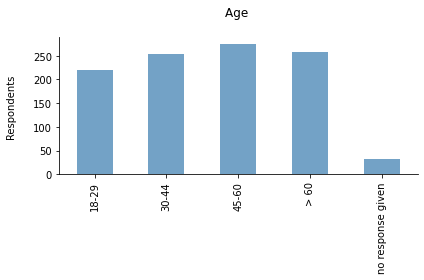

In [7]:
df_age=etiq[col_n['age']].groupby(etiq[col_n['age']]).size()
title='Age \n'
color='#73a2c6'
ax=df_age.plot.bar(xlabel='', ylabel='Respondents \n', title=title, color=color)
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)
plt.tight_layout()

### QUESTION: Are senior passengers more chatty?

Is there a relationship between age and attitudes toward engaging in conversation with fellow passengers during a flight?

One could argue that older generations may be more open to conversation, whereas younger passengers might prefer using their electronic devices and avoiding interactions.

###### Survey question: 'Generally speaking, is it rude to say more than a few words to the stranger sitting next to you on a plane?'
###### Respondents had 3 answers to choose from. Let's assign quantitative values to them for an easier comparison:
      'No, not at all rude' = 0
      'Yes, somewhat rude' = 1
      'Yes, very rude' = 2

In [8]:
#creating function to assign numeric values based on answers (this will be used repeatedly)

def assign_val(df1, df2, c_from, c_to):
    for i in df1.index:
        if df1.at[i,c_from]=='No, not at all rude':
            df2.at[i,c_to]=0
        elif df1.at[i,c_from]=='No, not rude at all':
            df2.at[i,c_to]=0
        elif df1.at[i,c_from]=='Yes, somewhat rude':
            df2.at[i,c_to]=1
        elif df1.at[i,c_from]=='Yes, very rude':
            df2.at[i,c_to]=2

            
df_age_talk=etiq[[col_n['age'], col_n['talk']]]
assign_val(df_age_talk, df_age_talk, col_n['talk'], 'Talk attitude indicator')
df_age_talk=df_age_talk.drop(col_n['talk'], axis=1)
df_age_talk=df_age_talk[df_age_talk[col_n['age']]!='no response given']  #excluding rows with no age data
#calculating a mean of attitude values for each age group
df_age_talk_mean=df_age_talk.groupby(col_n['age']).mean().round(2) #NAs are skipped by default
                                                                    
#Average results for age groups on a scale from 0 ("not rude at all") to 2 ("very rude"):
df_age_talk_mean

,Talk attitude indicator
Age,
18-29,0.24
30-44,0.27
45-60,0.22
> 60,0.23


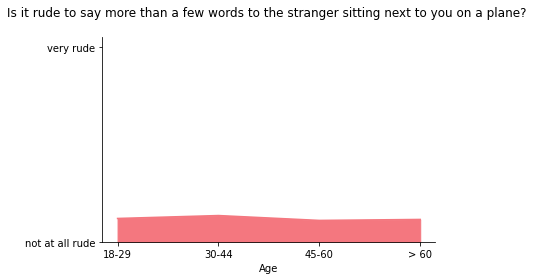

In [9]:
#area plot

title="Is it rude to say more than a few words to the stranger sitting next to you on a plane? \n"
color='#f4777f'
df_age_talk_mean.plot.area(title=title, color=color, legend=False) #plotting

#setting axis range and labels
ticks=['not at all rude', 'very rude']
plt.ylim(0, 2.1) 
plt.yticks(ticks=[0, 2], labels=ticks)
plt.xticks(ticks=[0,1,2,3])

sns.despine()
plt.tight_layout()

### CONCLUSION: Slight increase in openness to conversation among passengers over 45

The results reveal no significant difference in attitudes toward talking, as measured by the weighted indicator. However, individuals over 45 appear to be the most open to conversing with a stranger on a plane, which aligns with the initial prediction.

#### Let's see if there are any age-related differences in the TOTAL numbers of people who have negative attitude towards talking to strangers onboard (regardless whether it is 'very' or 'somewhat' negative)

In [10]:
#grouping by age respondents answering 'not rude'
df_age_talk_N=df_age_talk[df_age_talk['Talk attitude indicator']==0].groupby('Age').size()
df_age_talk_N=df_age_talk_N.to_frame().reset_index()
df_age_talk_N.columns=['Age', 'Not rude']

#grouping by age respondents answering 'very' or 'somewhat' rude
df_age_talk_Y=df_age_talk[df_age_talk['Talk attitude indicator'].isin([1, 2])].groupby('Age').size()
df_age_talk_Y=df_age_talk_Y.to_frame().reset_index()
df_age_talk_Y.columns=['Age', 'Rude']

#merging both dataframes
df_age_talk_m=df_age_talk_Y.merge(df_age_talk_N)  
df_age_talk_m=df_age_talk_m.set_index('Age')
df_age_talk_m=round(df_age_talk_m.div(df_age_talk_m.sum(axis=1), axis=0), 2)*100  #percentage by age buckets
df_age_talk_perc=df_age_talk_m.style.format('{:.0f}%'.format) #number format to percentage
df_age_talk_perc

,Rude,Not rude
Age,,
18-29,21%,79%
30-44,23%,77%
45-60,19%,81%
> 60,20%,80%


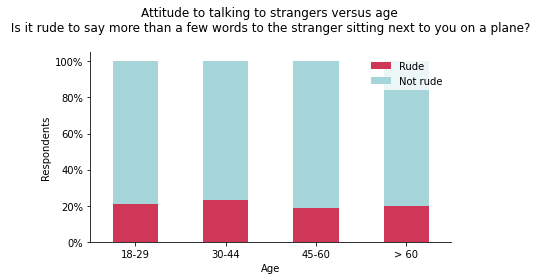

In [11]:
#bar chart: age vs. talk

title='Attitude to talking to strangers versus age \n Is it rude to say more than a few words to the stranger sitting next to you on a plane? \n'
color=['#cf3759', '#a5d5d8']
ax=df_age_talk_m.plot.bar(stacked=True, rot=0, color=color, title=title, ylabel='Respondents')
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)
ax.yaxis.set_major_formatter(tcr.PercentFormatter())
leg = plt.legend()
leg.get_frame().set_linewidth(0.0)  #removing legend border
plt.tight_layout()

#### CONCLUSION: As previously shown, passengers were a bit more likely to enjoy small talk over the age of 45, although it was not a major difference.

Consistently with previous results, the data shows that individuals over 45 consider talking to a stranger on a plane slightly more acceptable than younger passengers, with those aged 30–44 being the most opposed.

Overall, though, all age groups overwhelmingly consider such behavior "not rude."

### GENDER structure of the respondents' group

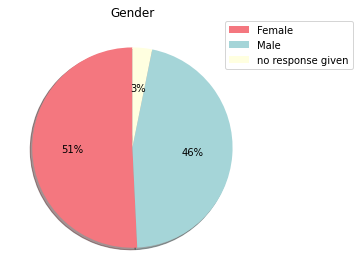

In [12]:
#gender ratio pie chart
df_g=etiq[col_n['gender']].groupby(etiq[col_n['gender']]).size()
colors=['#f4777f', '#a5d5d8', '#ffffe0']
title='Gender'
leg_labels=['Female', 'Male', 'no response given']
df_g.plot.pie(autopct='%.f%%', colors=colors, shadow=True, startangle=90, label='', labels=['','',''], title=title, \
              textprops={'color':"black"})
plt.legend(labels=leg_labels, bbox_to_anchor=(0.85,1), loc="upper left")
plt.tight_layout()

### QUESTION: Are there gender differences in perceiving rudeness?

Is one gender more prone to consider the behavior of others as violating norms? 
There is a considerable body of research proving that women try harder to act in a polite way. 
Does it mean that they would be more or less likely to judge certain behaviors as rude? 
Will they apply the same norms to others as to themselves and be more strict or contrary, will they be more forgiving?

In [13]:
#There are 9 columns with answers to 'is it rude?' type of questions

#listing 'is it rude?' columns
col_rude1=[col_n['unsold'], col_n['talk'], col_n['recl_rude'], col_n['switch_friend'], col_n['switch_family'], 
      col_n['wake_bath'], col_n['wake_walk'], col_n['baby'], col_n['unruly_child']] 

#finding all possible answers to the 'is it rude?' questions 
ans=[]
for c in etiq[col_rude1]:
    ans.extend(etiq[c].unique())

ans=pd.unique(ans)    #removing dups
ans

#negative answer has two forms depending on the column: 'No, not at all rude' and 'No, not rude at all'
#this has been incorporated to the definition of the assign_val function above

array(['no response given', 'No, not rude at all', 'Yes, somewhat rude',
       'Yes, very rude', 'No, not at all rude'], dtype=object)

In [14]:
#assiging numeric values to answers

col_g=[col_n['gender']]
col_rude2=['unsold', 'talk', 'recl_rude', 'switch_friend', 'switch_family', 'wake_bath', 'wake_walk', 
           'baby', 'unruly_child']   #listing column names for a new dataframe created below
df_rude=etiq[col_g + col_rude1]  #creating dataframe with gender and 'is it rude?' columns

for n in range(len(col_rude1)):  #using function assign_val defined above to assign numeric values to the answers
    assign_val(df_rude, df_rude, col_rude1[n], col_rude2[n])  

df_rude=df_rude.drop(col_rude1, axis=1)
df_rude.drop(df_rude[df_rude['Gender']=='no response given'].index, inplace=True)    #skip rows with no gender data
df_rude.dropna(inplace=True)    #skip rows with NaN

#calculating % of answers 'very'/'somewhat rude' vs. 'not rude' by gender
df_rude_1=df_rude.copy()
df_rude_1['not_rude_count']=df_rude_1[df_rude_1[col_rude2]==0].count(axis=1)
df_rude_1['rude_count']=df_rude_1[df_rude_1[col_rude2].isin([1,2])].count(axis=1)
df_rude_1.drop(col_rude2, axis=1, inplace=True)
df_rude_1['q_count']=9  #number of questions per respondent
df_rude_1=df_rude_1.groupby('Gender').sum()
df_rude_1['Answers \'rude\'']=round(df_rude_1['rude_count']/df_rude_1['q_count']*100, 0)
df_rude_1['Answers \'not rude\'']=round(df_rude_1['not_rude_count']/df_rude_1['q_count']*100, 0)
df_rude_1.drop(['not_rude_count', 'rude_count', 'q_count'], axis=1, inplace=True)

df_rude_1=df_rude_1.style.format('{:.0f}%'.format) #number format to percentage
df_rude_1

,Answers 'rude',Answers 'not rude'
Gender,,
Female,38%,62%
Male,40%,60%


### CONCLUSION: Women can forgive (a bit) more

Women were a bit less likely than men to evaluate behaviors as 'rude' (38% vs. 40% of answers). 
(Analysis without discriminating between 'very rude' and 'somewhat rude' answers.) 

### Let's see if a clearer pattern emerges when we also account for sentiment intensity: 'very rude' versus 'somewhat rude'

In [15]:
#calculating % of answers 'very rude' vs. 'somewhat rude' by gender
df_rude_2=df_rude.copy()
df_rude_2['very_rude']=df_rude_2[df_rude_2[col_rude2]==2].count(axis=1)
df_rude_2['somewhat_rude']=df_rude_2[df_rude_2[col_rude2]==1].count(axis=1)
df_rude_2.drop(col_rude2, axis=1, inplace=True)
df_rude_2['q_count']=9  #number of questions
df_rude_2=df_rude_2.groupby('Gender').sum()
df_rude_2['Answers \'very rude\'']=round(df_rude_2['very_rude']/df_rude_2['q_count'] * 100)
df_rude_2['Answers \'somewhat rude\'']=round(df_rude_2['somewhat_rude']/df_rude_2['q_count'] * 100)
df_rude_2.drop(['very_rude', 'somewhat_rude', 'q_count'], axis=1, inplace=True)
df_rude_2=df_rude_2.style.format('{:.0f}%'.format) #number format to percentage
df_rude_2

,Answers 'very rude',Answers 'somewhat rude'
Gender,,
Female,10%,28%
Male,12%,28%


### CONCLUSION: Slight gender differences in the intensity of dislike

We see that whereas there is no difference between both genders in calling a behavior as 'somewhat rude', men are a bit more likely to use the term 'very rude' (12% vs. 10% of all the answers by gender).

### QUESTION: What annoys women most? What bothers men?

Which questions triggered the most negative responses from men and women, respectively?

In [16]:
#creating dataframe with data on gender and answers
df_rude_3=df_rude.copy()   
df_rude_3['n']=1  #adding a column for the number of respondents (assigning '1' to each respondent at this point)
df_rude_3=df_rude_3.groupby('Gender').sum()  #grouping by gender
Q_list=['Q1', 'Q2', 'Q3', 'Q4', 'Q5', 'Q6', 'Q7', 'Q8', 'Q9']  #listing new column names (will be visible in the plot)
col_list=['unsold', 'talk', 'recl_rude', 'switch_friend', 'switch_family', 'wake_bath', 'wake_walk', 'baby', 'unruly_child']

#creating a numeric indicator of answers by dividing quantified answers by no. respondents for each gender:
df_rude_3[Q_list]=round(df_rude_3[col_list].div(df_rude_3['n'], axis=0), 3)  
df_rude_3.drop(col_rude2, axis=1, inplace=True)
df_rude_3.drop('n', axis=1, inplace=True)

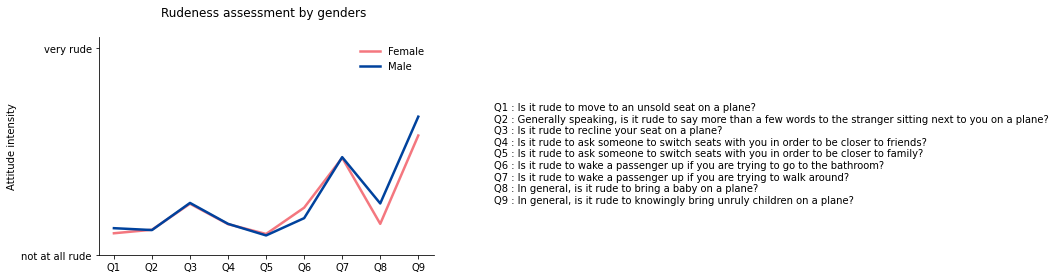

In [17]:
#line chart

df_rude_t=df_rude_3.copy()
df_rude_t
df_rude_t=df_rude_t.transpose()

questions = 'Q1 : Is it rude to move to an unsold seat on a plane?\
\nQ2 : Generally speaking, is it rude to say more than a few words to the stranger sitting next to you on a plane?\
\nQ3 : Is it rude to recline your seat on a plane?\
\nQ4 : Is it rude to ask someone to switch seats with you in order to be closer to friends?\
\nQ5 : Is it rude to ask someone to switch seats with you in order to be closer to family?\
\nQ6 : Is it rude to wake a passenger up if you are trying to go to the bathroom?\
\nQ7 : Is it rude to wake a passenger up if you are trying to walk around?\
\nQ8 : In general, is it rude to bring a baby on a plane?\
\nQ9 : In general, is it rude to knowingly bring unruly children on a plane?'

title='Rudeness assessment by genders \n'
ylabel='Attitude intensity' 
color=['#f4777f', '#00429d'] 
ax=df_rude_t.plot.line(yticks=None, title=title, color=color, linewidth=2.5) #creating line plot
ax.set_ylabel(ylabel)

new_ticks=['not at all rude', 'very rude']  #setting y axis range and labels
plt.ylim(0,2.1)
plt.yticks(ticks=[0, 2], labels=new_ticks) 

ax.spines['right'].set_visible(False) 
ax.spines['top'].set_visible(False)
plt.text(10, 0.5, questions)  #adding legend with questions 
plt.legend(frameon=False)

### CONCLUSION: Men and women generally agreed in their assessments of rudeness

The biggest differences occur in questions related to the presence of children on board (Q8 and Q9), with men being more critical than women.

### HOUSEHOLD INCOME distribution among the respondents

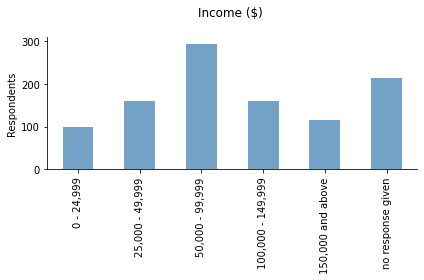

In [18]:
#column chart
df_income=etiq[col_n['income']].groupby(etiq[col_n['income']]).size()
df_income=df_income.reindex(['$0 - $24,999', '$25,000 - $49,999', '$50,000 - $99,999',\
                             '$100,000 - $149,999', '150000', 'no response given'])

ticks=range(6)
labels=['0 - 24,999', '25,000 - 49,999', '50,000 - 99,999', '100,000 - 149,999', '150,000 and above', 'no response given']
color='#73a2c6'
df_income.plot.bar(xlabel='', ylabel='Respondents', title='Income ($) \n', color=color)
plt.xticks(ticks=ticks, labels=labels)
sns.despine()
plt.tight_layout()

### HEIGHT by gender

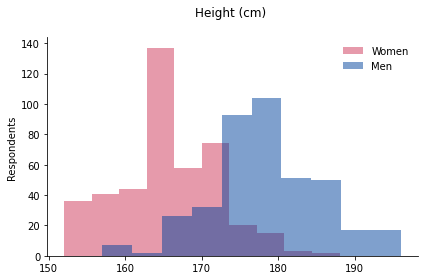

In [19]:
#overlapping histograms

#selecting height data for women
df_inc_w=etiq_raw[col_n['height']][etiq_raw[col_n['gender']]=='Female']  
df_inc_w=df_inc_w.to_frame()
df_inc_w.dropna(inplace=True)
df_inc_w.columns=['height']
outliers=['Under 5 ft.', '6\'6\" and above']
df_inc_w=df_inc_w[~df_inc_w['height'].isin(outliers)]  #removing outliers (total of 12 respondents)

#selecting height data for men
df_inc_m=etiq_raw[col_n['height']][etiq_raw[col_n['gender']]=='Male'] 
df_inc_m=df_inc_m.to_frame()
df_inc_m.dropna(inplace=True)
df_inc_m.columns=['height']
df_inc_m=df_inc_m[~df_inc_m['height'].isin(outliers)]  #removing outliers (total of 2 respondents)

#converting height from feet and inches to cm:
    # format: 6'3"
    # 1 foot = 30.48 cm
    # 1 inch = 2.54 cm

def parse_h(a):  #creating function for convertion
    h=a.split("'")
    f=float(h[0])
    i=float(h[1].replace("\"", ""))
    m=round(f*30.48 + i*2.54)
    return m

df_inc_w['height_cm']=df_inc_w['height'].apply(lambda x : parse_h(x))
df_inc_m['height_cm']=df_inc_m['height'].apply(lambda x : parse_h(x))

plt.figure(figsize=(6,4))
colorw='#cf3759'
colorm='#00429d'

plt.hist(df_inc_w['height_cm'], bins=10, color=colorw, alpha=0.5, label="Women")
plt.hist(df_inc_m['height_cm'], bins=10, color=colorm, alpha=0.5, label="Men")

plt.title('Height (cm) \n')
plt.ylabel('Respondents')
plt.legend(loc='upper right')
sns.despine()
plt.legend(frameon=False)

plt.tight_layout()

###### The height distribution is close to normal for both genders, with extreme heights occuring relatively rarely and average being the most common.

### QUESTION: Do taller respondents report higher income?

It has been repeatedly proven that taller persons (especialy men) tend to earn more. 
Let's check if this holds true in our group of respondents.

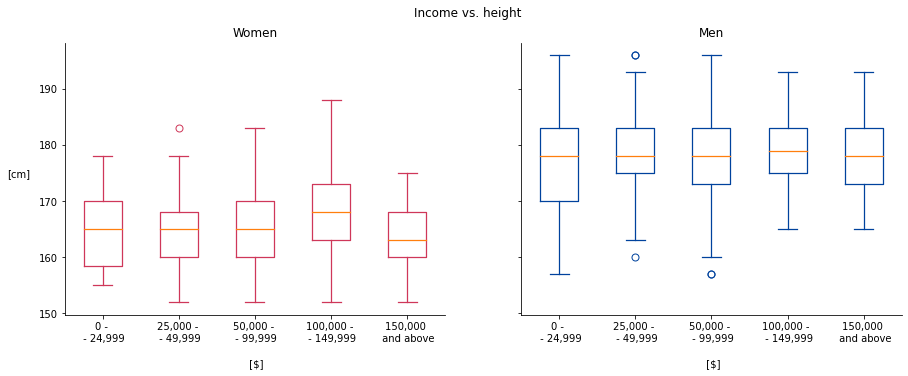

In [20]:
#box plots

#creating dataframe
df_inc=etiq_raw[[col_n['gender'], col_n['height'], col_n['income']]]
df_inc.dropna(inplace=True, axis=0)
df_inc.columns=['gender', 'height', 'income']
df_inc=df_inc[df_inc['height']!='Under 5 ft.']  #removing outliers (total of 14 respondents)
df_inc=df_inc[df_inc['height']!='6\'6\" and above']
df_inc=df_inc.reset_index(drop='True')

#converting height from feet and inches to cm with the parse_h function defined above
df_inc['height_cm']=df_inc['height'].apply(lambda x : parse_h(x))

#creating lists containing height values in cm for the box plot (one list per income range)
#women
inc1_w=[]    #'$0 - $24,999'
inc2_w=[]    #'$25,000 - $49,999'
inc3_w=[]    #'$50,000 - $99,999'
inc4_w=[]    #'$100,000 - $149,999'
inc5_w=[]    #'150000'
#men
inc1_m=[]    #'$0 - $24,999'
inc2_m=[]    #'$25,000 - $49,999'
inc3_m=[]    #'$50,000 - $99,999'
inc4_m=[]    #'$100,000 - $149,999'
inc5_m=[]    #'150000'

for i in df_inc.index:
    if df_inc.at[i, 'gender']=='Female':
        if df_inc.at[i, 'income']=='$0 - $24,999':
            inc1_w.append(df_inc.at[i, 'height_cm'])
        elif df_inc.at[i, 'income']=='$25,000 - $49,999':
            inc2_w.append(df_inc.at[i, 'height_cm'])
        elif df_inc.at[i, 'income']=='$50,000 - $99,999':
            inc3_w.append(df_inc.at[i, 'height_cm'])
        elif df_inc.at[i, 'income']=='$100,000 - $149,999':
            inc4_w.append(df_inc.at[i, 'height_cm'])
        elif df_inc.at[i, 'income']=='150000':
            inc5_w.append(df_inc.at[i, 'height_cm'])
    elif df_inc.at[i, 'gender']=='Male':
        if df_inc.at[i, 'income']=='$0 - $24,999':
            inc1_m.append(df_inc.at[i, 'height_cm'])
        elif df_inc.at[i, 'income']=='$25,000 - $49,999':
            inc2_m.append(df_inc.at[i, 'height_cm'])
        elif df_inc.at[i, 'income']=='$50,000 - $99,999':
            inc3_m.append(df_inc.at[i, 'height_cm'])
        elif df_inc.at[i, 'income']=='$100,000 - $149,999':
            inc4_m.append(df_inc.at[i, 'height_cm'])
        elif df_inc.at[i, 'income']=='150000':
            inc5_m.append(df_inc.at[i, 'height_cm'])

#datasets
inc_w=[inc1_w, inc2_w, inc3_w, inc4_w, inc5_w]  
inc_m=[inc1_m, inc2_m, inc3_m, inc4_m, inc5_m]
inc=[inc_w, inc_m]

#creating plot
fig, axs=plt.subplots(ncols=2, figsize=(15,5), sharey=True)  

#customization
labels=['0 - \n - 24,999', '25,000 - \n - 49,999', '50,000 - \n - 99,999', '100,000 - \n - 149,999', '150,000 \n and above']
fig.suptitle('Income vs. height \n')  
axs[0].set_title('Women')
axs[0].set_ylabel('[cm]', rotation=0, labelpad=20)
axs[1].set_title('Men')
color=['#cf3759', '#00429d']

for n in [0,1]:
    axs[n].boxplot(inc[n], boxprops=dict(color=color[n], linewidth=1.25), whiskerprops=dict(color=color[n], linewidth=1.25), 
               capprops=dict(color=color[n], linewidth=1.25), medianprops=dict(linewidth=1.25), 
                   flierprops=dict(markeredgecolor=color[n], markersize=7))  

for ax in axs.flat:
    ax.set(xlabel='\n [$]', xticklabels=labels)
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)

### CONCLUSION: No clear relationship between height and income

**Women**

For women, there is a gradual increase in the spread of the 4th quartile across income ranges from `$25,000` to `$149,999`. However, the median increases only between the 3rd and 4th income brackets. While this might suggest a slight correlation between height and income, further statistical analysis (analysis of correlation) would be required to confirm it.

On the other hand, height data for the highest income bracket (`$150,000` and above) contradicts our hypothesis—all metrics (min/max values, quartiles, and median) are the lowest across the dataset.

**Men**

Data for men offers even less support for the hypothesis. The only statistic aligned with our prediction is the spread of the bottom quartile, which trends downward as income increases, whereas the median remains stable across all brackets. While the 2nd quartile is lowest in the lowest income bracket, the remaining brackets show no steady growth. Contrary to expectations, the 4th quartile peaks in the lowest and middle income ranges.


Overall, the results do not support the expected increase in income with greater height.

Potential explanations include:

* Household Income vs. Individual Salary: The data reflects household income rather than personal earnings. Household income can stem from multiple sources (partner's earnings, investments, royalties, inheritance) that are unlikely to be influenced by an individual's height.

* Binned Data Structure: Income is recorded in discrete, unequal ranges rather than exact continuous values, which limits granularity. 

### EDUCATION

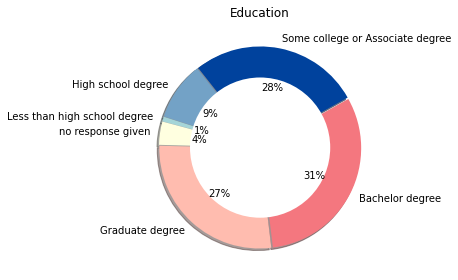

In [21]:
#donut plot of educational degrees distribution

df_g=etiq[col_n['edu']].groupby(etiq[col_n['edu']]).size()
df_g=df_g.reindex(['Less than high school degree', 'High school degree', 'Some college or Associate degree', 
                   'Bachelor degree', 'Graduate degree', 'no response given'])

colors = ['#a5d5d8', '#73a2c6', '#00429d', '#f4777f', '#ffbcaf', '#ffffe0']
explode=[0.01, 0.01, 0.01, 0.01, 0.01, 0.01]
fig=df_g.plot.pie(autopct='%.f%%', colors=colors, shadow=True, explode=explode, startangle=165, label='', 
                  title='Education', counterclock=False)
centre_circle = plt.Circle((0,0),0.70,fc='white')
fig.add_artist(centre_circle)
plt.tight_layout()

### QUESTION: Is there a relationship between educational degree and frequency of flying?

An exploratory investigation without assuming any direction of the possible relationship.

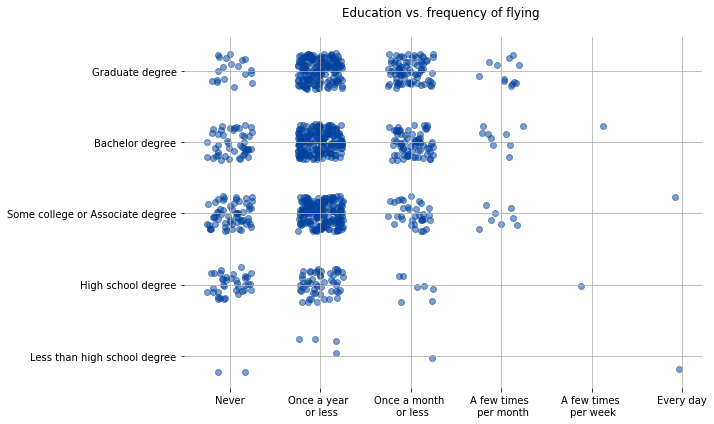

In [22]:
#scatter plot (with noise)

#preparing data for plotting
df_edf=pd.DataFrame()
            
#converting string categorical data into integers for plotting
for i in etiq.index:
    if etiq.at[i, col_n['freq']]=='Never':
        df_edf.at[i, 'frequency']=0
    elif etiq.at[i, col_n['freq']]=='Once a year or less':
        df_edf.at[i, 'frequency']=1
    elif etiq.at[i, col_n['freq']]=='Once a month or less':
        df_edf.at[i, 'frequency']=2
    elif etiq.at[i, col_n['freq']]=='A few times per month':
        df_edf.at[i, 'frequency']=3
    elif etiq.at[i, col_n['freq']]=='A few times per week':
        df_edf.at[i, 'frequency']=4
    elif etiq.at[i, col_n['freq']]=='Every day':
        df_edf.at[i, 'frequency']=5

for i in etiq.index:
    if etiq.at[i, col_n['edu']]=='no response given':
        df_edf.at[i, 'education']=0
    elif etiq.at[i, col_n['edu']]=='Less than high school degree':
        df_edf.at[i, 'education']=1  
    elif etiq.at[i, col_n['edu']]=='High school degree':
        df_edf.at[i, 'education']=2 
    elif etiq.at[i, col_n['edu']]=='Some college or Associate degree':
        df_edf.at[i, 'education']=3 
    elif etiq.at[i, col_n['edu']]=='Bachelor degree':
        df_edf.at[i, 'education']=4 
    elif etiq.at[i, col_n['edu']]=='Graduate degree':
        df_edf.at[i, 'education']=5 

#remove rows with no response regarding education
for i in df_edf.index:
    if df_edf.at[i,'education']==0:
        df_edf.drop(labels=i, axis=0, inplace=True)

#adding noise to the data for the purpose of making the plot easier to read
# (Normally with categorical data a scatter plot would show only a few points. 
# To get a sense of how many observations there are in each point random noise will be added. 
# This way the points will not overlap that much.)
xnoise, ynoise=np.random.random(len(df_edf))/2, np.random.random(len(df_edf))/2  #noise in 0-0.5 range

#plotting the scatterplot
title="Education vs. frequency of flying \n"
plt.figure(figsize=(10,6))
color='#00429d'
plt.scatter(df_edf['frequency']+xnoise, df_edf['education']+ynoise, alpha=0.5, color=color)
plt.title(title)
#setting ticks to '+.25' value to match the center of the noise distribution
plt.xticks(ticks=[0.25, 1.25, 2.25, 3.25, 4.25, 5.25], labels=['Never', 'Once a year \n or less', 'Once a month \n or less',
                                                               'A few times \n per month', 'A few times \n per week', 'Every day'])
plt.yticks(ticks=[1.25, 2.25, 3.25, 4.25, 5.25], labels=['Less than high school degree', 'High school degree', 
                                                               'Some college or Associate degree',
                                                               'Bachelor degree', 'Graduate degree'])
plt.grid()
sns.despine(left=True, bottom=True)
plt.tight_layout()

### CONCLUSION:
The most common flying frequency reported by respondents across all educational groups is "Once a year or less."

There seems to be a relationship between educational degree and flying frequency. With each higher education level, there is a larger proportion of respondents reporting more frequent flights (after adjusting for different group sizes). To explore this potential relationship further, other statistical methods, such as correlation analysis, would need to be used.

### Number of CHILDREN under 18

<Figure size 864x432 with 0 Axes>

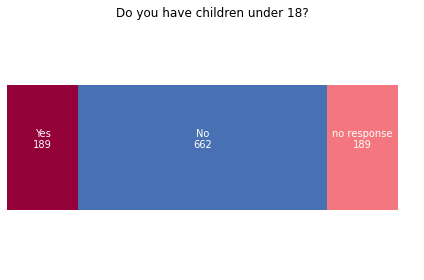

In [23]:
#horizontal stacked bar chart showing number of participants (not)having children under 18 years of age

df_c=pd.DataFrame()
y=etiq[col_n['child']].value_counts().Yes
df_c['Yes']=[y]
n=etiq[col_n['child']].value_counts().No
df_c['No']=[n]
r=len(etiq[col_n['child']])-y-n
df_c['no response']=[r]

colors=['#93003a', '#4771b2', '#f4777f']
title="Do you have children under 18?"

#plotting the chart
plt.figure(figsize=(12,6))
ax=df_c.plot.barh(stacked=True, title=title, legend=False, color=colors)

#adding labels
d=0
for i in df_c.columns:   
    plt.text(df_c.loc[0,i]/2 + d, 0, i + '\n' + str(df_c.loc[0, i]), ha='center', color='#FFFFFF', 
             size=11, stretch='condensed') 
    d=d+df_c.loc[0,i]

#removing axes, ticks and labels
plt.box(on=False)
plt.xticks(ticks=[], labels='')
plt.yticks(ticks=[], labels='')

plt.tight_layout()

### QUESTION: Are parents more understanding towards other children's behavior on a plane?

Is there a relationship between having children under 18 and attitudes toward bringing babies and unruly children on a flight?

To get an overview of respondents' attitudes in a single graph, let's create an indicator that reflects both the attitude and its intensity.

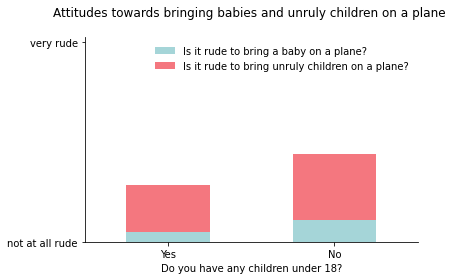

In [24]:
#stacked column plot with weighted indicator of attitudes towards taking babies and unruly children on a plane
#comparing parents of children under 18 with the remaining respondents

#creating dataframe for the plot
df_child=etiq[[col_n['child'], col_n['baby'], col_n['unruly_child']]]

#using previously defined assign_val function to assign integer values to answers regarding rudeness
    #  'No, not at all rude' = 0
    #  'Yes, somewhat rude' = 1
    #  'Yes, very rude' = 2
c_f=[col_n['baby'], col_n['unruly_child']]  #list of columns containing values to be converted
c_t=['baby_n', 'unruly_child_n']  #list of columns with integer values

for n in range(len(c_f)):
    assign_val(df_child, df_child, c_f[n], c_t[n])
#'baby_n' -  weighted indicator of respondents' attitude towards bringing babies on a plane
#'unruly_child_n' -  weighted indicator of respondents' attitude towards bringing unruly children on a plane


df_child_y=df_child[df_child[col_n['child']]=='Yes'][[col_n['child'],'baby_n', 'unruly_child_n']]
df_child_y=df_child_y.groupby(col_n['child']).sum(['baby_n', 'unruly_child_n'])/len(df_child_y)

df_child_n=df_child[df_child[col_n['child']]=='No'][[col_n['child'],'baby_n', 'unruly_child_n']]
df_child_n=df_child_n.groupby(col_n['child']).sum(['baby_n', 'unruly_child_n'])/len(df_child_n)

df_child_a=df_child_y.append(df_child_n)
df_child_a.columns=['Is it rude to bring a baby on a plane?', 'Is it rude to bring unruly children on a plane?']


#plotting the chart
new_ticks=['not at all rude', 'very rude']
colors=['#a5d5d8', '#f4777f']

ax=df_child_a.plot.bar(stacked=True, rot=0, color=colors)
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)
plt.legend(frameon=False)

plt.ylim(0,4.1)
plt.yticks(ticks=[0, 4], labels=new_ticks) 
plt.title('Attitudes towards bringing babies and unruly children on a plane \n')
plt.tight_layout()

#### To back the above column plot with precise data let's create a data table showing percentage of respondents in each group.

In [25]:
#data table

#creating a dataframe 
df_y_b=etiq[[col_n['child'], col_n['baby']]] [etiq[col_n['child']]=='Yes']
df_y_b.drop(df_y_b[df_y_b[col_n['baby']]=='no response given'].index, inplace=True)
df_y_b=df_y_b.groupby(col_n['baby']).size()/len(df_y_b)
df_y_b=df_y_b.to_frame()
df_y_b.index.name = 'Answer'
df_y_b.columns=['HAVE CHILD - Is it rude to bring a baby on a plane?']

df_y_ch=etiq[[col_n['child'], col_n['unruly_child']]] [etiq[col_n['child']]=='Yes']
df_y_ch.drop(df_y_ch[df_y_ch[col_n['unruly_child']]=='no response given'].index, inplace=True)
df_y_ch=df_y_ch.groupby(col_n['unruly_child']).size()/len(df_y_ch)
df_y_ch=df_y_ch.to_frame()
df_y_ch.index.name = 'Answer'
df_y_ch.columns=['HAVE CHILD - Is it rude to bring unruly children on a plane?']

df_n_b=etiq[[col_n['child'], col_n['baby']]] [etiq[col_n['child']]=='No']
df_n_b.drop(df_n_b[df_n_b[col_n['baby']]=='no response given'].index, inplace=True)
df_n_b=df_n_b.groupby(col_n['baby']).size()/len(df_n_b)
df_n_b=df_n_b.to_frame()
df_n_b.index.name = 'Answer'
df_n_b.columns=['DO NOT HAVE CHILD - Is it rude to bring a baby on a plane?']

df_n_ch=etiq[[col_n['child'], col_n['unruly_child']]] [etiq[col_n['child']]=='No']
df_n_ch.drop(df_n_ch[df_n_ch[col_n['unruly_child']]=='no response given'].index, inplace=True)
df_n_ch=df_n_ch.groupby(col_n['unruly_child']).size()/len(df_n_ch)
df_n_ch=df_n_ch.to_frame()
df_n_ch.index.name = 'Answer'
df_n_ch.columns=['DO NOT HAVE CHILD - Is it rude to bring unruly children on a plane?']

data_frames=[df_y_b, df_n_b, df_y_ch, df_n_ch]
df_child_merged=reduce(lambda left, right: pd.merge(left, right, on =['Answer'], how='outer'), data_frames)  #merging data

#headers and formatting
headers=[np.array(['Is it rude to bring a baby on a plane?', 'Is it rude to bring a baby on a plane?', 
                   'Is it rude to bring unruly children on a plane?', 'Is it rude to bring unruly children on a plane?']), 
        np.array(['Have child', 'No child', 'Have child', 'No child'])]
df_child_merged.columns=headers  #updating 2-level headers

df_child_merged_p=df_child_merged.style.format('{:.0%}'.format)  #number format to percentage
df_child_merged_p


#### For better readability let's add color coding to the table above.

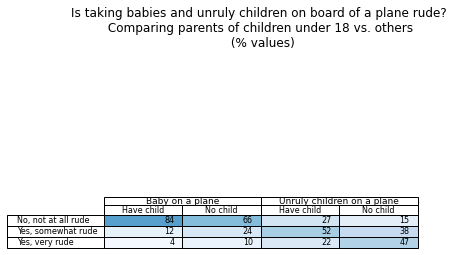

In [26]:
#table with color coding

#creating dataframe
df_child_merged_t=df_child_merged*100
df_child_merged_t=df_child_merged_t.round().astype(int)

fig, ax=plt.subplots(1,1)

#defining colors
norm = cl.Normalize(vmin=0, vmax=150)
colors = plt.cm.Blues(norm(df_child_merged_t.values))

#headers and formatting
header = plt.table(cellText=[['']*2],
                      colLabels=['Baby on a plane', 'Unruly children on a plane'],
                      loc='bottom')

ch_table=plt.table(cellText=df_child_merged_t.values, 
                   rowLabels=df_child_merged_t.index, 
                   colLabels=['Have child', 'No child', 'Have child', 'No child'], 
                   colWidths=[0.9]*len(df_child_merged.columns), 
                   loc='bottom', bbox=[0, -0.35, 1.0, 0.3],
                   cellColours=colors)
ax.set_title("Is taking babies and unruly children on board of a plane rude? \n Comparing parents of children under 18 vs. others \n (% values)")
ch_table.auto_set_font_size(False)
ch_table.set_fontsize(8)
ax.axis('off')

plt.tight_layout()

### CONCLUSION: Yes, parents are more forgiving towards other kids, too

It is clear that individuals who have children under 18 are more open to the presence of babies and children (even unruly ones) on board a plane. Data also shows that there is much broader public acceptance toward bringing babies on a plane than unruly children.

### HISTORY OF VIOLATING SAFETY RULES on board of a plane

### QUESTION: Are people who violate rules themselves more willing to turn a blind eye to others?

Is there a relationship between violating security rules and the level of permissiveness towards other passangers?

Do people who admit to have violated norms (use of electronics during take off or landing,  smoking on board) also accept all sorts of troublesome behavior from others (for example: frequent getting up, waking another passenger, reclining seat, switching seats, bringing children)?

For this comparison, only frequent flyers' answers will be considered, as they have the highest likelihood of both violating rules and developing experience-based attitudes toward other passengers. Answers categorized as "frequent flyers" include: "Once a month or less", "A few times per month", "A few times per week", and "Every day".

In [27]:
#selecting data
ff = ['Once a month or less', 'A few times per month', 'A few times per week', 'Every day'] #frequent flyers
col_rude1 = [col_n['unsold'], col_n['talk'], col_n['recl_rude'], col_n['switch_friend'], col_n['switch_family'], 
      col_n['wake_bath'], col_n['wake_walk'], col_n['baby'], col_n['unruly_child']] #questions of 'is it rude?' type
col_norm1 = [col_n['electronics'], col_n['smoke']] #questions about violating norms 

col_rude2 = ['unsold', 'talk', 'recl_rude', 'switch_friend', 'switch_family', 'wake_bath', 'wake_walk', 'baby', \
           'unruly_child']  #values assigned to the 'is it rude?' answers
col_norm2 = ['electronics', 'smoke'] #values assigned to the questions about violating norms 

df_norms = etiq[etiq[col_n['freq']].isin(ff)][col_rude1 + col_norm1] #filtering for frequent flyers

In [28]:
#assiging values to the 'is it rude' columns

for n in range(len(col_rude1)):
    assign_val(df_norms, df_norms, col_rude1[n], col_rude2[n])  #using function assign_val defined above


In [29]:
#assigning values to the 'norms violation' columns

def assign_val_YN(df1, df2, c_from, c_to):  
    for i in df1.index:
        if df1.at[i,c_from]=='No':
            df2.at[i,c_to]=0
        elif df1.at[i,c_from]=='Yes':
            df2.at[i,c_to]=1   
    
for n in range(len(col_norm1)):
    assign_val_YN(df_norms, df_norms, col_norm1[n], col_norm2[n])

In [30]:
#drop unnecessary columns

for c in col_rude1:
    df_norms.drop(c, inplace=True, axis=1)

for c in col_norm1:
    df_norms.drop(c, inplace=True, axis=1)
    
    
#drop rows with NAs
df_norms.dropna(inplace=True)

#checking if sufficient data is left for further analysis
len(df_norms)
#235 rows of data remained

235

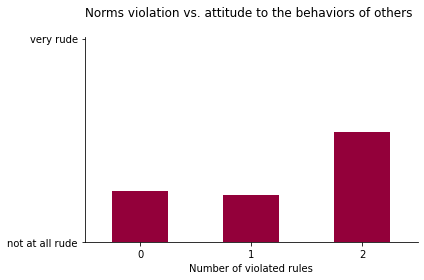

In [31]:
#summing up the answers to norm- and rudeness-related questions

df_norms['Rudeness assessment']=df_norms[col_rude2].sum(axis=1)  
df_norms['Number of violated rules']=df_norms[col_norm2].sum(axis=1)

#creating buckets for respondents violating 0 / 1 / 2 norms and calculating average of their 'rudeness' answers

df_norms_2=df_norms[['Number of violated rules', 'Rudeness assessment']]
df_norms_mean=df_norms_2.groupby('Number of violated rules').mean()
df_norms_mean=df_norms_mean.round(2)
df_norms_mean=df_norms_mean.reindex([0, 1, 2]) #removing decimals from x labels

#column chart

title='Norms violation vs. attitude to the behaviors of others \n'
new_ticks=['not at all rude', 'very rude']
color='#93003a'
ax = df_norms_mean.plot.bar(rot=0, color=color, title=title, legend='')
plt.ylim(0, 18.1)
plt.yticks(ticks=[0, 18], labels=new_ticks) 
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)
plt.tight_layout()

In [32]:
#data behind the chart ('rudeness assessment' min=0, max=18)
df_norms_mean

,Rudeness assessment
Number of violated rules,
0,4.47
1,4.14
2,9.75


In [33]:
#checking the number of respondents in each group
df_norms_size=df_norms_2.groupby('Number of violated rules').size()  
df_norms_size

Number of violated rules
0.0    172
1.0     59
2.0      4
dtype: int64

### CONCLUSION: "It's OK when I break the rules, but not when you do"

Contrary to expectations, respondents who reported violating security rules most frequently were actually the least forgiving of other potentially disruptive behaviors.Respondents who admitted to violating both rules (smoking and using electronics) rated behaviors such as switching seats, reclining seats, or walking around as "rude" more frequently than those who broke only one rule or none at all.However, these results should be interpreted with caution due to the small sample size of "double-violation" passengers ($n = 4$).